# I audited my own trading system — and killed my best result

For five months I ran an automated signal system (news + technicals + derivatives, LLM-synthesized)
against crypto and US equities, paper-trading every call. By July 2026 the log showed a **positive
net expectancy per trade** — the kind of number that tempts you toward real money.

This notebook is the audit that number failed. It asks three questions any data professional should
ask of their own favorable result:

1. **Is the sample what it claims to be?** (It wasn't — demo trades and non-trades inside the headline count.)
2. **Is the inference honest about dependence?** (It wasn't — same-day signals are one bet, not thirty.)
3. **Does it beat doing nothing?** (Unproven — a do-nothing always-long baseline is statistically indistinguishable.)

Everything below runs from `../data/trades.csv` — the complete trade log, one row per paper trade.
No hidden state; re-run it yourself.

**Conventions** (inherited from the live system so numbers match production):
round-trip fee + slippage = **0.30%** per trade; SELL trades store `pnl_pct` profit-oriented
(price falling ⇒ positive pnl); a trade is *gross correct* if the profit-oriented move is positive.

In [1]:
import numpy as np, pandas as pd, json, pathlib
import matplotlib.pyplot as plt

FEE_RT = 0.30          # % round-trip fee+slippage, matches the live paper books
rng = np.random.default_rng(29)   # fixed seed: every CI below reproduces exactly

df = pd.read_csv("../data/trades.csv", parse_dates=["entry_date"])
df = df[df.evaluated].copy()
df["day"] = pd.to_datetime(df.entry_date, utc=True, format="mixed").dt.date
df["net"] = df.pnl_pct - FEE_RT

demo  = df[df.is_demo]
holds = df[~df.is_demo & (df.signal == "HOLD")]
real  = df[~df.is_demo & df.signal.isin(["BUY", "SELL"])].copy()
real["win"] = real.pnl_pct > 0   # gross correct, derived from the profit-oriented pnl

print(f"evaluated rows: {len(df)}  ({df.day.min()} → {df.day.max()})")
print(f"  demo trades:     {len(demo):>4}  ← '[Demo]'-tagged dry-run period, inside the headline count")
print(f"  HOLD advisories: {len(holds):>4}  ← not directional bets, yet logged and graded as trades")
print(f"  real BUY/SELL:   {len(real):>4}  on {real.day.nunique()} trading days — the sample that matters")

evaluated rows: 2412  (2026-02-04 → 2026-07-08)
  demo trades:      419  ← '[Demo]'-tagged dry-run period, inside the headline count
  HOLD advisories:  415  ← not directional bets, yet logged and graded as trades
  real BUY/SELL:   1578  on 90 trading days — the sample that matters


## 1 · The naive read

Treat every trade as an independent observation and the system looks alive: positive net expectancy,
and an ordinary (iid) bootstrap happily calls it significant.

In [2]:
def boot_iid(x, n=3000):
    x = np.asarray(x); m = np.array([rng.choice(x, len(x)).mean() for _ in range(n)])
    return np.percentile(m, [2.5, 97.5])

acc_gross = real.win.mean() * 100
net_exp   = real.net.mean()
ci_iid    = boot_iid(real.net)
print(f"real trades          n = {len(real)}")
print(f"gross accuracy       {acc_gross:.1f}%")
print(f"net expectancy       {net_exp:+.3f}%/trade")
print(f"iid bootstrap 95% CI [{ci_iid[0]:+.3f}, {ci_iid[1]:+.3f}]"
      + ("   ← 'significant'" if ci_iid[0] > 0 else ""))

real trades          n = 1578
gross accuracy       53.7%
net expectancy       +0.479%/trade
iid bootstrap 95% CI [+0.154, +0.825]   ← 'significant'


## 2 · The dependence problem

The iid bootstrap assumes 1,578 independent bets. But the system fires many signals per day on
correlated assets — when BTC gaps down, ETH, SOL and the miners gap with it. **Same-day trades are
one market bet, not thirty.** The honest resampling unit is the *trading day*: resample whole days
with replacement, carrying every trade inside each picked day.

In [3]:
def boot_day(frame, col, n=3000):
    groups = [g[col].values for _, g in frame.groupby("day")]
    idx = np.arange(len(groups))
    means = np.empty(n)
    for i in range(n):
        picked = np.concatenate([groups[j] for j in rng.choice(idx, len(groups))])
        means[i] = picked.mean()
    return means

boot_net = boot_day(real, "net")
ci_day = np.percentile(boot_net, [2.5, 97.5])
print(f"effective sample     {real.day.nunique()} days (not {len(real)} trades)")
print(f"net expectancy       {net_exp:+.3f}%/trade   (same point estimate)")
print(f"day-clustered 95% CI [{ci_day[0]:+.3f}, {ci_day[1]:+.3f}]"
      + ("   ← includes zero" if ci_day[0] <= 0 <= ci_day[1] else ""))

effective sample     90 days (not 1578 trades)
net expectancy       +0.479%/trade   (same point estimate)
day-clustered 95% CI [-0.181, +1.102]   ← includes zero


Same data, same point estimate — the only thing that changed is respecting the dependence
structure, and the evidence for an edge evaporates. This is the difference between *n* = trades
and *n* = independent bets.

## 3 · The baseline nobody wants to run

A signal system doesn't compete with zero — it competes with **doing nothing intelligent**.
Feb–Jul 2026 was a broadly rising tape, so the fair null is *always-BUY on the identical
instances*: same entry, same exit, same fee, signal ignored. `pnl_pct` is profit-oriented,
so the raw market move is `pnl` for BUY and `−pnl` for SELL.

In [4]:
real["move"] = np.where(real.signal == "BUY", real.pnl_pct, -real.pnl_pct)
real["excess"] = real.pnl_pct - real.move            # fee cancels in the difference

base_rate = (real.move > 0).mean() * 100             # up-move base rate
boot_exc = boot_day(real, "excess")
ci_exc = np.percentile(boot_exc, [2.5, 97.5])
print(f"always-BUY net       {(real.move - FEE_RT).mean():+.3f}%/trade")
print(f"system net           {net_exp:+.3f}%/trade")
print(f"excess vs always-BUY {real.excess.mean():+.3f}%/trade,  day-clustered 95% CI [{ci_exc[0]:+.3f}, {ci_exc[1]:+.3f}]"
      + ("  ← includes zero" if ci_exc[0] <= 0 <= ci_exc[1] else ""))
print(f"gross accuracy {acc_gross:.1f}%  vs  up-move base rate {base_rate:.1f}%")

always-BUY net       +0.325%/trade
system net           +0.479%/trade
excess vs always-BUY +0.153%/trade,  day-clustered 95% CI [-0.328, +0.723]  ← includes zero
gross accuracy 53.7%  vs  up-move base rate 53.9%


## 4 · The confidence score carries no information

Every signal ships with a 1–10 confidence score. It **gates logging** (<6 discarded) and **scales
paper position sizes** — so it had better correlate with outcomes.

In [5]:
conf_r = np.corrcoef(real.confidence, real.pnl_pct)[0, 1]
print(f"corr(confidence, pnl) = {conf_r:+.3f}  across {len(real)} real trades")
print("a score that sizes positions and filters the log — indistinguishable from noise")

corr(confidence, pnl) = -0.015  across 1578 real trades
a score that sizes positions and filters the log — indistinguishable from noise


## Figures

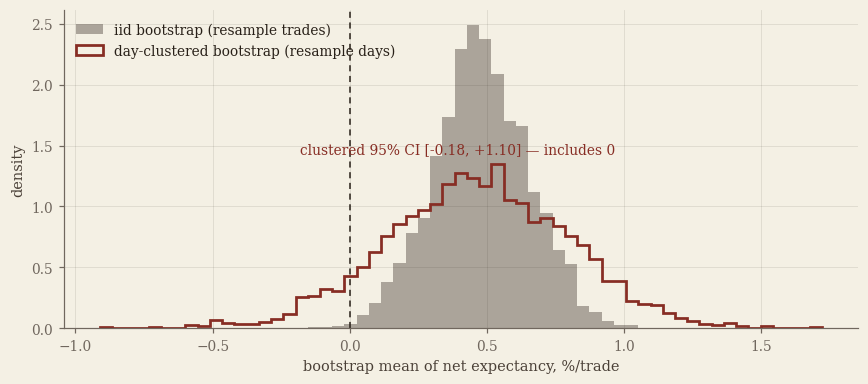

In [6]:
# paper-workbench figure theme (repo DESIGN.md tokens)
PAPER, PAPER_DEEP = "#f4f0e4", "#eee8d9"
INK, INK_SOFT, INK_FAINT = "#282018", "#4a4037", "#70675e"
RUBRIC, HAIR = "#872d24", (.16, .13, .09, .28)
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "font.family": "serif", "svg.fonttype": "none",
    "text.color": INK, "axes.edgecolor": INK_FAINT, "axes.labelcolor": INK_SOFT,
    "xtick.color": INK_FAINT, "ytick.color": INK_FAINT, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": INK, "grid.alpha": .10, "grid.linewidth": .6,
    "axes.titlesize": 11, "axes.labelsize": 9.5, "figure.dpi": 110,
})
FIGS = pathlib.Path("../docs/figures"); FIGS.mkdir(exist_ok=True)

# Fig 1 — two bootstrap distributions of the same estimate
fig, ax = plt.subplots(figsize=(8, 3.6))
iid_means = np.array([rng.choice(real.net.values, len(real)).mean() for _ in range(3000)])
bins = np.linspace(min(iid_means.min(), boot_net.min()), max(iid_means.max(), boot_net.max()), 60)
ax.hist(iid_means, bins=bins, density=True, color=INK_FAINT, alpha=.55, label="iid bootstrap (resample trades)")
ax.hist(boot_net, bins=bins, density=True, histtype="step", color=RUBRIC, lw=1.8,
        label="day-clustered bootstrap (resample days)")
ax.axvline(0, color=INK, lw=1, ls=(0, (4, 3)))
ax.annotate(f"clustered 95% CI [{ci_day[0]:+.2f}, {ci_day[1]:+.2f}] — includes 0",
            (ci_day[0], ax.get_ylim()[1]*.55), fontsize=9, color=RUBRIC)
ax.set_xlabel("bootstrap mean of net expectancy, %/trade"); ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout(); fig.savefig(FIGS / "fig1-bootstrap.svg"); plt.show()

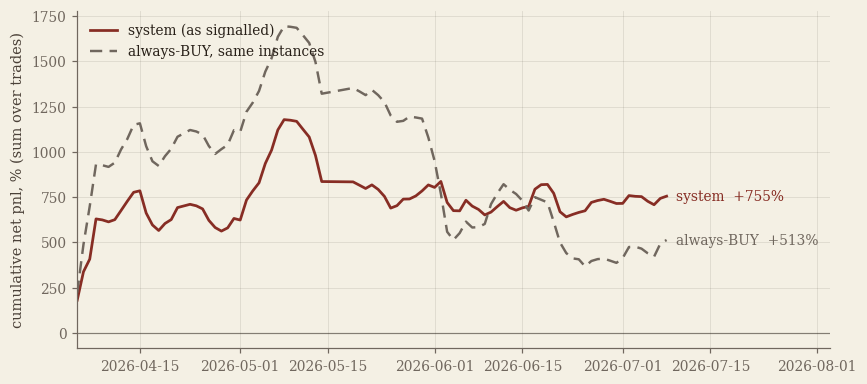

In [7]:
# Fig 2 — cumulative net pnl: system vs always-BUY on identical instances
daily = real.groupby("day")[["net", "move"]].sum().sort_index()
daily["base_net"] = daily.move - FEE_RT * real.groupby("day").size()
cum_sys, cum_base = daily.net.cumsum(), daily.base_net.cumsum()
x = pd.to_datetime(daily.index)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(x, cum_sys, color=RUBRIC, lw=1.8, label="system (as signalled)")
ax.plot(x, cum_base, color=INK_FAINT, lw=1.6, ls=(0, (5, 3)), label="always-BUY, same instances")
ax.axhline(0, color=INK, lw=.8, alpha=.5)
for series, lab, c in ((cum_sys, "system", RUBRIC), (cum_base, "always-BUY", INK_FAINT)):
    ax.annotate(f"{lab}  {series.iloc[-1]:+.0f}%", (x[-1], series.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", fontsize=9, color=c, va="center")
ax.set_xlim(x[0], x[-1] + pd.Timedelta(days=26))
ax.set_ylabel("cumulative net pnl, % (sum over trades)")
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout(); fig.savefig(FIGS / "fig2-cumulative.svg"); plt.show()

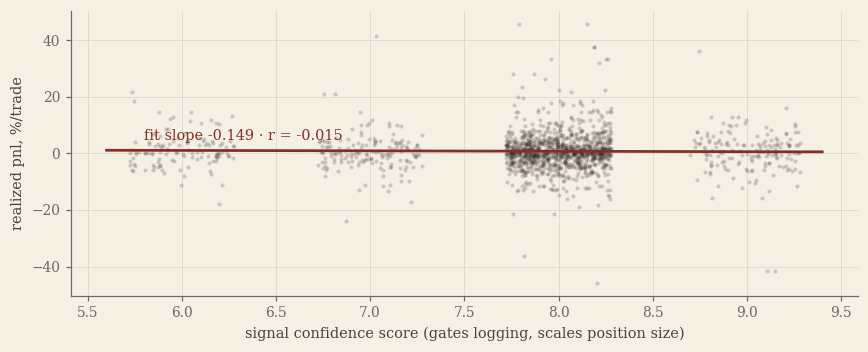

In [8]:
# Fig 3 — the confidence score vs realized pnl
fig, ax = plt.subplots(figsize=(8, 3.3))
jit = real.confidence + rng.uniform(-.28, .28, len(real))
ax.scatter(jit, real.pnl_pct, s=7, color=INK, alpha=.20, linewidths=0)
cx = np.array([real.confidence.min() - .4, real.confidence.max() + .4])
b, a = np.polyfit(real.confidence, real.pnl_pct, 1)
ax.plot(cx, a + b * cx, color=RUBRIC, lw=1.8)
ax.annotate(f"fit slope {b:+.3f} · r = {conf_r:+.3f}", (cx[0] + .2, a + b * cx[0] + 3.5),
            fontsize=9.5, color=RUBRIC)
ax.set_xlabel("signal confidence score (gates logging, scales position size)")
ax.set_ylabel("realized pnl, %/trade")
fig.tight_layout(); fig.savefig(FIGS / "fig3-confidence.svg"); plt.show()

## Verdict — and what it changed

**No demonstrable edge.** The point estimate is positive, but once trades are clustered by day the
95% CI includes zero; the excess over an always-long baseline on identical instances is small and
its CI includes zero too; and gross accuracy (53.7%) doesn't clear the period's up-move base rate
(53.9%) — a coin that always calls "up" would have matched the signal layer. The confidence score
that sizes positions is noise (r ≈ −0.015).

The number I wanted was real. The evidence for it wasn't. What changed because of this audit:

- **Promotion to live capital is now a mechanical gate**, not a feeling: day-clustered CI > 0 *and*
  positive excess vs always-BUY, sustained over ≥ 60 trading days of post-fix data.
- **The honesty layer moved into the pipeline** — the production dashboard now reports the
  day-clustered CI and the always-BUY excess next to every headline metric, so the flattering
  number can never appear without its context again.
- **The confidence score is being retired from position sizing** until it demonstrates correlation
  with outcomes out of sample.

A positive result would have been more fun. A defensible process is worth more.

In [9]:
# machine-readable results consumed by the case-study page (docs/)
results = {
  "window": [str(real.day.min()), str(real.day.max())],
  "n_evaluated": int(len(df)), "n_real": int(len(real)), "n_demo": int(len(demo)),
  "n_days_real": int(real.day.nunique()),
  "acc_gross_real": round(float(acc_gross), 1),
  "base_rate_up": round(float(base_rate), 1),
  "net_exp_real": round(float(net_exp), 3),
  "ci_iid": [round(float(v), 3) for v in ci_iid],
  "ci_day": [round(float(v), 3) for v in ci_day],
  "always_buy_net": round(float((real.move - FEE_RT).mean()), 3),
  "excess_mean": round(float(real.excess.mean()), 3),
  "ci_excess": [round(float(v), 3) for v in ci_exc],
  "conf_corr": round(float(conf_r), 3),
  "fee_rt_pct": FEE_RT,
}
pathlib.Path("../data/results.json").write_text(json.dumps(results, indent=2))
results

{'window': ['2026-04-05', '2026-07-08'],
 'n_evaluated': 2412,
 'n_real': 1578,
 'n_demo': 419,
 'n_days_real': 90,
 'acc_gross_real': 53.7,
 'base_rate_up': 53.9,
 'net_exp_real': 0.479,
 'ci_iid': [0.154, 0.825],
 'ci_day': [-0.181, 1.102],
 'always_buy_net': 0.325,
 'excess_mean': 0.153,
 'ci_excess': [-0.328, 0.723],
 'conf_corr': -0.015,
 'fee_rt_pct': 0.3}